In [14]:
# Generate simulated temperature readings from two sensors.
# Sensor A: mean 25 C, std 3 C, 200 readings.
# Sensor B: mean 27 C, std 4.5 C, 200 readings.
# Also generate 200 timestamps uniformly from 0 to 10 seconds.
# Use np.random.default_rng with a seed = last 4 digits of your Drexel ID.

seed = 6012  # replace with your last 4 digits
rng = np.random.default_rng(seed)

n = 200
timestamps = rng.uniform(0, 10, size=n)  # renamed from t

sensor_a = rng.normal(loc=25.0, scale=3.0, size=n)  # renamed from sensor_A
sensor_b = rng.normal(loc=27.0, scale=4.5, size=n)  # renamed from sensor_B

sensor_a.shape

(200,)

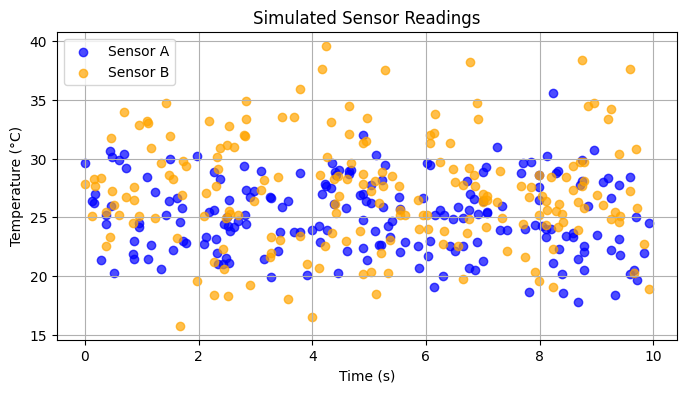

In [15]:
# Scatter plot: sensor reading (y-axis) vs timestamp in seconds (x-axis).
# Color Sensor A points blue and Sensor B points orange.
# Add axis labels with units, a title, and a legend.

plt.figure(figsize=(8,4))

plt.scatter(timestamps, sensor_a, color='blue', alpha=0.7, label='Sensor A')
plt.scatter(timestamps, sensor_b, color='orange', alpha=0.7, label='Sensor B')

plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Simulated Sensor Readings')
plt.legend()
plt.grid(True)

plt.show()

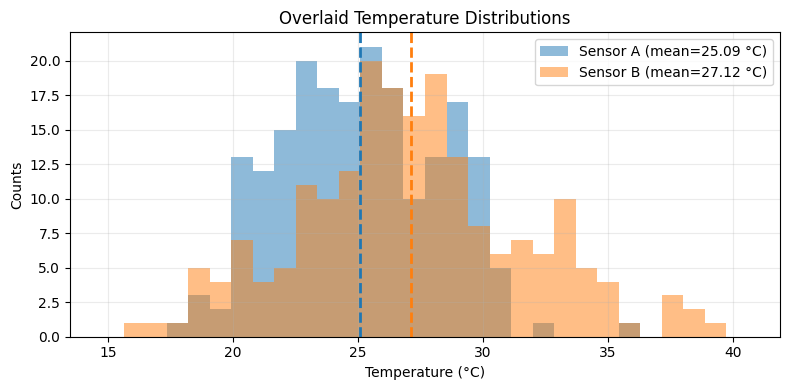

In [16]:
# Overlaid histogram of Sensor A and Sensor B temperature distributions.
# Use 30 bins, alpha=0.5 for transparency so both distributions are visible.
# Add vertical dashed lines at each sensor's mean.
# Include a legend labeling each sensor.

plt.figure(figsize=(8,4))
bins = np.linspace(min(sensor_a.min(), sensor_b.min()) - 1,
max(sensor_a.max(), sensor_b.max()) + 1, 31) # 30 bins
plt.hist(sensor_a, bins=bins, alpha=0.5, color='C0',
label=f'Sensor A (mean={sensor_a.mean():.2f} °C)')
plt.hist(sensor_b, bins=bins, alpha=0.5, color='C1',
label=f'Sensor B (mean={sensor_b.mean():.2f} °C)')
plt.axvline(sensor_a.mean(), color='C0', linestyle='--', linewidth=2)
plt.axvline(sensor_b.mean(), color='C1', linestyle='--', linewidth=2)
plt.xlabel('Temperature (°C)')
plt.ylabel('Counts')
plt.title('Overlaid Temperature Distributions')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7672/496978214.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Sensor A', 'Sensor B'], patch_artist=True,


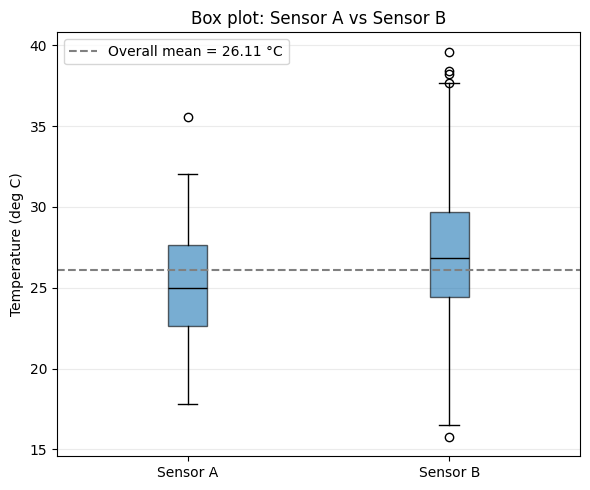

In [17]:
# Side-by-side box plot comparing Sensor A and Sensor B distributions.
# Label x-axis with sensor names, y-axis with "Temperature (deg C)".
# Add a horizontal dashed line at the overall mean of both sensors combined.

plt.figure(figsize=(6,5))
data = [sensor_a, sensor_b]
plt.boxplot(data, labels=['Sensor A', 'Sensor B'], patch_artist=True,
            boxprops=dict(facecolor='C0', edgecolor='k', alpha=0.6),
            medianprops=dict(color='k'))
overall_mean = np.concatenate(data).mean()
plt.axhline(overall_mean, color='gray', linestyle='--', linewidth=1.5,
            label=f'Overall mean = {overall_mean:.2f} °C')
plt.ylabel('Temperature (deg C)')
plt.title('Box plot: Sensor A vs Sensor B')
plt.legend()
plt.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.show()